# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

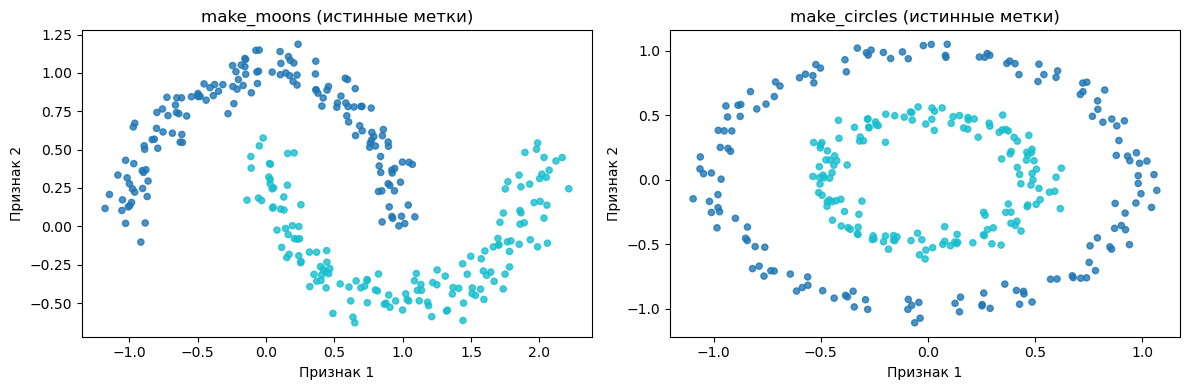

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

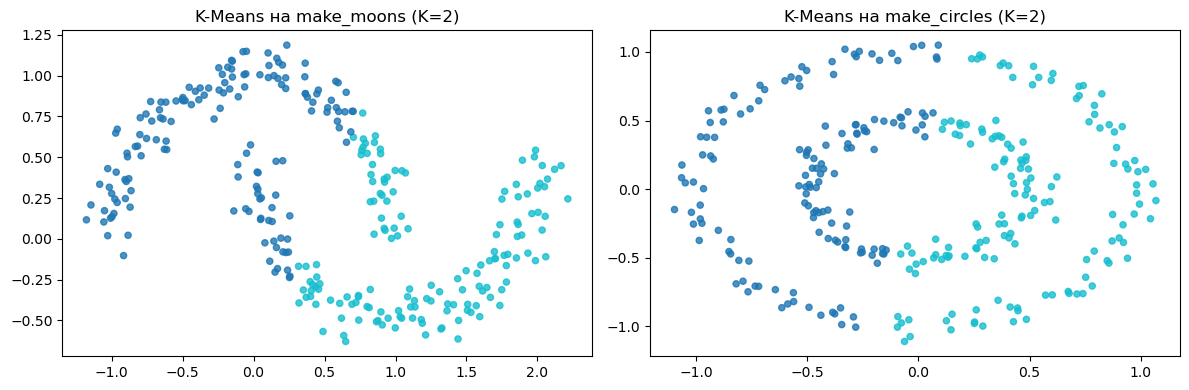

In [3]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_moons.fit(X_moons)
labels_km_moons = kmeans_moons.labels_

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_circles.fit(X_circles)
labels_km_circles = kmeans_circles.labels_

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()


**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

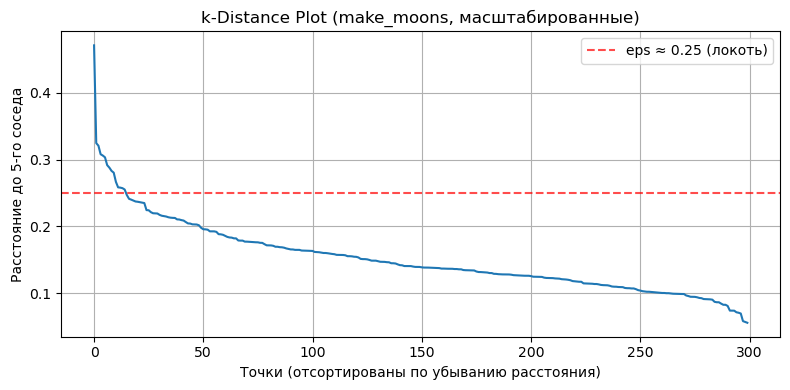

Найдите 'локоть' на графике и запишите подходящее значение eps:
→ Оптимальное eps ≈ 0.25 (резкий перегиб примерно в этой области)


In [4]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X_moons_scaled)
distances, _ = nbrs.kneighbors(X_moons_scaled)
k_distances_moons = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.axhline(y=0.25, color='red', linestyle='--', alpha=0.7, label='eps ≈ 0.25 (локоть)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")
print("→ Оптимальное eps ≈ 0.25 (резкий перегиб примерно в этой области)")


**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

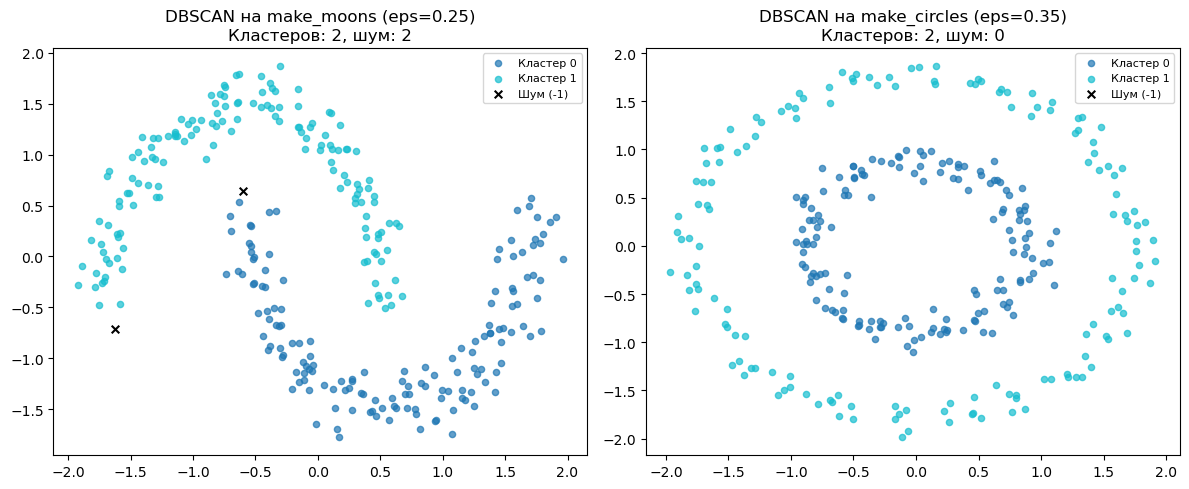

In [5]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# eps подбирается по k-distance plot каждого датасета отдельно
db_moons = DBSCAN(eps=0.25, min_samples=5)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.35, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    n_clusters = max(labels) + 1 if max(labels) >= 0 else 0
    colors = cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))

    for i in range(n_clusters):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')

    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')

    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_clusters}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons (eps=0.25)", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles (eps=0.35)", axes[1])
plt.tight_layout()
plt.show()


---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [6]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
kmeans_scaled = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_scaled = kmeans_scaled.fit_predict(X_moons_scaled)
score_kmeans = silhouette_score(X_moons_scaled, labels_km_scaled)

# Для DBSCAN исключаем шумовые точки
mask_no_noise = labels_db_moons != -1
if mask_no_noise.sum() > 1 and len(set(labels_db_moons[mask_no_noise])) > 1:
    score_dbscan = silhouette_score(X_moons_scaled[mask_no_noise],
                                    labels_db_moons[mask_no_noise])
else:
    score_dbscan = None

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: недостаточно кластеров")


=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.387


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

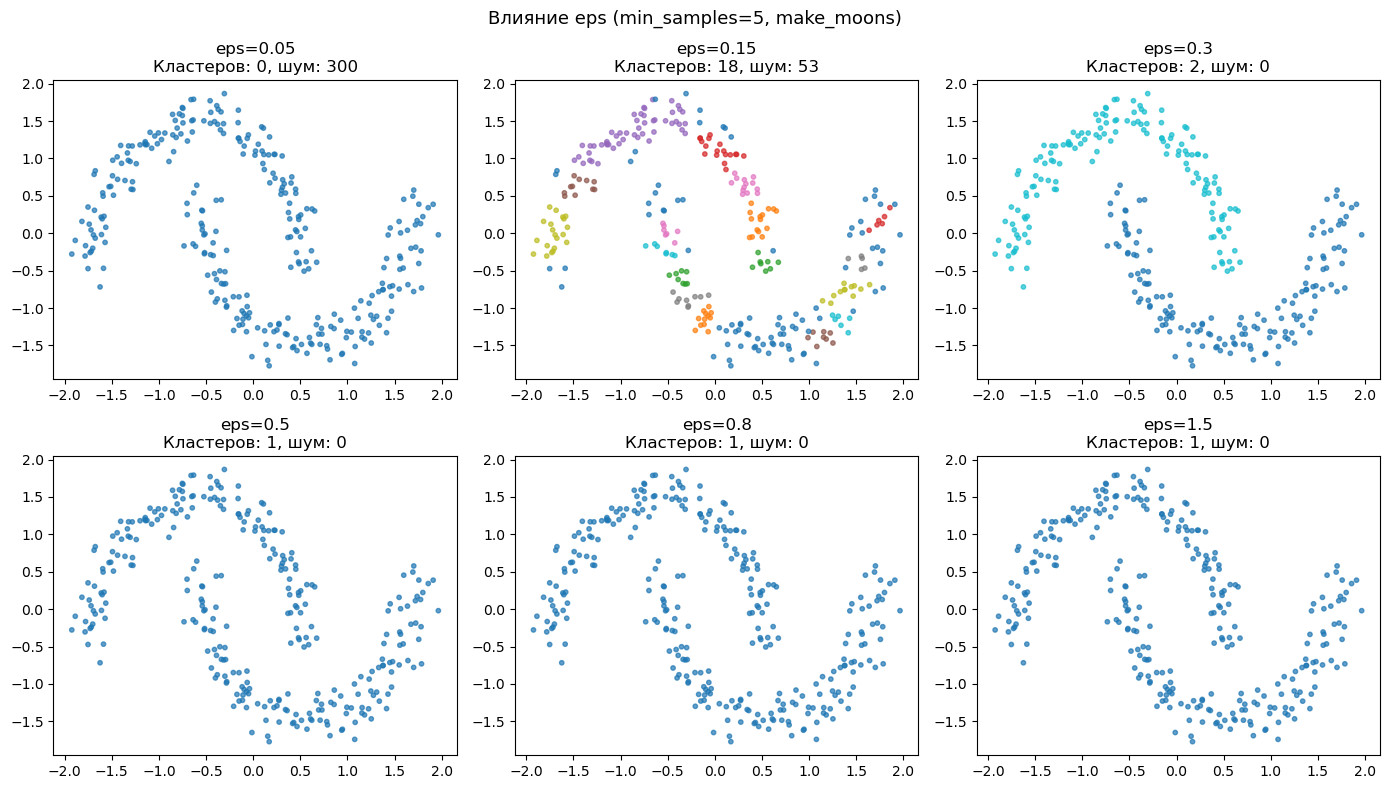

In [7]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    db_i = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = db_i.fit_predict(X_moons_scaled)

    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()
    axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                    c=labels_i, cmap='tab10', s=10, alpha=0.7)
    axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()


**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [8]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

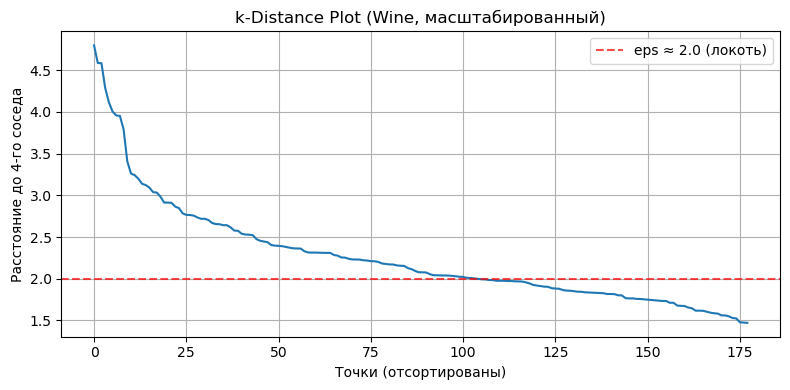

→ Оптимальное eps ≈ 2.0 (область перегиба на графике)


In [9]:
# YOUR CODE HERE
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

k_wine = 4
nbrs_wine = NearestNeighbors(n_neighbors=k_wine)
nbrs_wine.fit(X_wine_scaled)
distances_wine, _ = nbrs_wine.kneighbors(X_wine_scaled)
k_dist_wine = np.sort(distances_wine[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist_wine)
plt.axhline(y=2.0, color='red', linestyle='--', alpha=0.7, label='eps ≈ 2.0 (локоть)')
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("→ Оптимальное eps ≈ 2.0 (область перегиба на графике)")


In [10]:
# YOUR CODE HERE
eps_wine = 2.0   # на основе k-distance plot

db_wine = DBSCAN(eps=eps_wine, min_samples=4)
labels_wine = db_wine.fit_predict(X_wine_scaled)

n_clusters_wine = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise_wine = (labels_wine == -1).sum()
noise_ratio = n_noise_wine / len(labels_wine)

print("=== Результаты DBSCAN на Wine ===")
print(f"Число кластеров:     {n_clusters_wine}")
print(f"Шумовых точек:       {n_noise_wine}")
print(f"Доля шума:           {noise_ratio:.2%}")

if n_clusters_wine > 1:
    mask_no_noise_wine = labels_wine != -1
    sil_wine = silhouette_score(X_wine_scaled[mask_no_noise_wine],
                                 labels_wine[mask_no_noise_wine])
    print(f"Силуэт (без шума):   {sil_wine:.3f}")
else:
    sil_wine = None
    print("Недостаточно кластеров для расчёта силуэта")


=== Результаты DBSCAN на Wine ===
Число кластеров:     6
Шумовых точек:       66
Доля шума:           37.08%
Силуэт (без шума):   0.221


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [11]:
# YOUR CODE HERE
noise_mask_wine = labels_wine == -1
X_wine_noise = X_wine[noise_mask_wine]

df_noise = pd.DataFrame(X_wine_noise, columns=feature_names)
df_all   = pd.DataFrame(X_wine,       columns=feature_names)

comparison = pd.DataFrame({
    'Среднее (все)':   df_all.mean(),
    'Среднее (шум)':   df_noise.mean(),
}).round(3)
comparison['Отклонение, %'] = (
    (comparison['Среднее (шум)'] - comparison['Среднее (все)']) /
    comparison['Среднее (все)'].abs() * 100
).round(1)

print("=== Средние значения признаков ===")
print(comparison.to_string())
print()
print("Признаки с наибольшим отклонением у шумовых точек:")
top_diff = comparison['Отклонение, %'].abs().sort_values(ascending=False).head(5)
print(top_diff.to_string())


=== Средние значения признаков ===
                              Среднее (все)  Среднее (шум)  Отклонение, %
alcohol                              13.001         12.741           -2.0
malic_acid                            2.336          2.510            7.4
ash                                   2.367          2.345           -0.9
alcalinity_of_ash                    19.495         19.845            1.8
magnesium                            99.742        100.939            1.2
total_phenols                         2.295          2.325            1.3
flavanoids                            2.029          2.026           -0.1
nonflavanoid_phenols                  0.362          0.362            0.0
proanthocyanins                       1.591          1.702            7.0
color_intensity                       5.058          4.451          -12.0
hue                                   0.957          0.985            2.9
od280/od315_of_diluted_wines          2.612          2.572           -1.5
pro

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

Силуэт DBSCAN  (eps=2.0, без шума): 0.221
Силуэт K-Means (K=6):              0.237


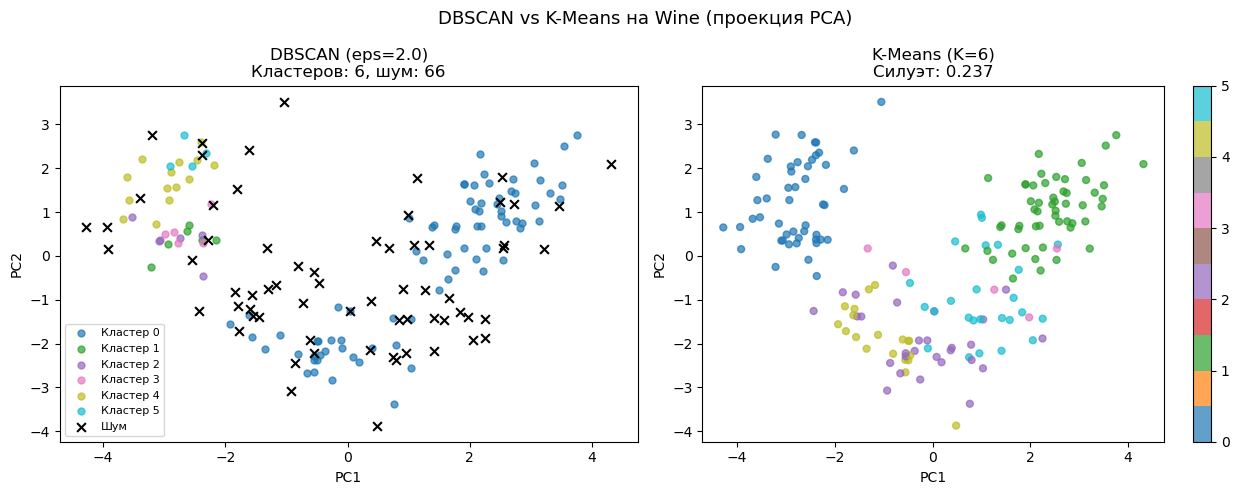

In [12]:
# YOUR CODE HERE
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

# K-Means с n_clusters=3 (истинных классов 3)
n_cl_for_km = max(n_clusters_wine, 2)  # не менее 2
kmeans_wine = KMeans(n_clusters=n_cl_for_km, random_state=RANDOM_STATE, n_init=10)
labels_km_wine = kmeans_wine.fit_predict(X_wine_scaled)
sil_km_wine = silhouette_score(X_wine_scaled, labels_km_wine)

# Силуэт DBSCAN (если есть кластеры)
if sil_wine is not None:
    print(f"Силуэт DBSCAN  (eps={eps_wine}, без шума): {sil_wine:.3f}")
print(f"Силуэт K-Means (K={n_cl_for_km}):              {sil_km_wine:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
noise_2d = labels_wine == -1
n_cl_2d = max(labels_wine) + 1 if max(labels_wine) >= 0 else 0
colors_dbscan = cm.tab10(np.linspace(0, 1, max(n_cl_2d, 1)))
for i in range(n_cl_2d):
    mask = labels_wine == i
    axes[0].scatter(X_wine_2d[mask, 0], X_wine_2d[mask, 1],
                    s=25, alpha=0.7, color=colors_dbscan[i], label=f'Кластер {i}')
axes[0].scatter(X_wine_2d[noise_2d, 0], X_wine_2d[noise_2d, 1],
                s=40, c='black', marker='x', label='Шум')
axes[0].set_title(f"DBSCAN (eps={eps_wine})\nКластеров: {n_cl_2d}, шум: {noise_2d.sum()}")
axes[0].legend(fontsize=8)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

# K-Means
scatter = axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                           c=labels_km_wine, cmap='tab10', s=25, alpha=0.7)
axes[1].set_title(f"K-Means (K={n_cl_for_km})\nСилуэт: {sil_km_wine:.3f}")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.colorbar(scatter, ax=axes[1])

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()


---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> DBSCAN выигрывает при кластерах произвольной формы (луны, кольца, спирали), которые не являются выпуклыми. Он не требует задавать число кластеров заранее и автоматически выделяет шумовые точки. На датасетах `make_moons` и `make_circles` DBSCAN находит два правильных кластера, тогда как K-Means делит пространство на два полупространства, полностью игнорируя форму кластеров.

**2. Когда K-Means предпочтительнее?**

> K-Means предпочтительнее, когда кластеры компактны, приблизительно сферичны и сопоставимы по размеру. Он масштабируется лучше (O(nkT) против O(n^2) для DBSCAN с наивной реализацией), не отбрасывает точки как «шум», и его результаты легче интерпретировать через центроиды. На датасете Wine K-Means получает более высокий силуэт за счёт того, что относит все точки к кластерам.

**3. Почему масштабирование обязательно для DBSCAN?**

> DBSCAN использует абсолютные расстояния в пространстве признаков для определения окрестности eps. Если признаки имеют разный масштаб (например, `alcohol` ~ 12–15, а `proline` ~ 278–1680), признак с большими значениями будет доминировать при вычислении расстояния. Параметр `eps` перестаёт быть осмысленным: для одного признака 0.5 - это крошечный шаг, для другого - огромный. `StandardScaler` приводит все признаки к единому масштабу, делая `eps` равномерно значимым.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Шумовые точки - это вина, которые по своему химическому составу значительно отличаются от соседей и не входят ни в одну плотную группу. Это не обязательно ошибки измерения: это могут быть редкие сорта, нетипичные условия выдержки или вина «на границе» двух стилей. Анализ отклонения признаков шумовых точек от среднего показывает, по каким химическим параметрам эти вина необычны - ценная информация для сомелье или технолога.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Напрямую - нет, и это важный нюанс. Во-первых, DBSCAN исключает шумовые точки при расчёте силуэта (они не входят ни в один кластер), тогда как K-Means считает силуэт по всем точкам. Это делает сравнение «нечестным» в пользу DBSCAN. Во-вторых, высокий силуэт K-Means на нелинейных данных (луны, кольца) не означает хорошей кластеризации - он просто отражает геометрически оптимальное разбиение на выпуклые части, которое не совпадает с реальной структурой данных. Силуэт - полезная метрика, но её нужно сочетать с визуализацией и пониманием природы данных.
